# Molecular Property Prediction — pic50 Regression

This notebook is structured in three parts:
- **Part 1** — Data preparation: featurise molecules, save `.parquet` (MLP) and `.pt` (GNN)
- **Part 2** — Splitting: random and scaffold splits for both modalities
- **Part 3** — Model experimentation tracked with MLflow

Assumes you already ran the ChEMBL SQL query and saved results as `chembl_data.parquet`.

## Imports & Setup

In [23]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from collections import defaultdict

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

# PyTorch + PyG
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GINEConv, AttentiveFP, global_mean_pool, global_add_pool

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# MLflow
import mlflow
import mlflow.pytorch

# Misc
import json
import math
import copy
import os

SEED         = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Setup complete.')
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

Setup complete.


In [24]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR  = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

RAW_PARQUET  = 'C:\\Users\\natalia\\Documents\\Studia\\Warsztaty_sztucznej_inteligencji\\Warsztaty_sztucznej_inteligencji\\data\\chembl_joined_2147_20260604_215317.parquet'    # your raw ChEMBL export
MLP_PARQUET  = DATA_DIR / 'mlp_features_2147_mlp_special.parquet'   # prepared MLP features
GNN_PT       = DATA_DIR / 'gnn_graphs_2147_gnn_special.pt'          # prepared GNN graphs

MLFLOW_DIR   = Path('.mlruns')

---
# Part 1 — Data Preparation

Goals:
- Light cleaning (keep as much data as possible — ~2000 rows)
- Deduplicate by SMILES → median pic50
- Build Morgan fingerprint + physicochemical feature matrix for MLP
- Build atom/bond graph objects for GNN

### 1.1 Load & minimal clean

In [25]:
df_raw = pd.read_parquet(RAW_PARQUET)
print(f'Raw rows: {len(df_raw):,}')
print(df_raw.dtypes)
df_raw.head(3)

Raw rows: 2,522
activity_id               int64
molregno                  int64
standard_value          float64
standard_units           object
standard_type            object
standard_relation        object
pchembl_value           float64
pic50                   float64
has_validity_comment       bool
assay_type               object
assay_organism           object
assay_relationship       object
confidence_score          int64
target_chembl_id         object
target_name              object
organism                 object
canonical_smiles         object
mw_freebase             float64
alogp                   float64
hba                     float64
hbd                     float64
psa                     float64
rtb                     float64
aromatic_rings          float64
qed_weighted            float64
dtype: object


,activity_id,molregno,standard_value,standard_units,standard_type,standard_relation,pchembl_value,pic50,has_validity_comment,assay_type,...,organism,canonical_smiles,mw_freebase,alogp,hba,hbd,psa,rtb,aromatic_rings,qed_weighted
0,1723376,349203,9200.0,nM,Ki,>,NaN,5.036212,False,B,...,homo sapiens,CCOc1nc(NC(C)=O)cc(N)c1C#N,220.23,0.89,5.0,2.0,101.03,3.0,1.0,0.79
1,1723466,349994,9200.0,nM,Ki,>,NaN,5.036212,False,B,...,homo sapiens,CCOc1nc(NC(=O)Cc2cc(OC)c(S(C)(=O)=O)cc2OC)cc(N...,443.91,2.32,8.0,2.0,129.84,8.0,2.0,0.64
2,1723467,349217,9200.0,nM,Ki,>,NaN,5.036212,False,B,...,homo sapiens,CC(=O)Nc1cc(N)c(C#N)c(-c2ccccc2)n1,252.28,2.16,4.0,2.0,91.80,2.0,2.0,0.86


In [26]:
# ── Step 1: drop rows without a SMILES or pic50 (hard requirement) ────────
df = df_raw.dropna(subset=['canonical_smiles', 'pic50']).copy()
print(f'After dropping null SMILES/pic50: {len(df):,}')

# ── Step 2: RDKit-validate SMILES ─────────────────────────────────────────
# Re-canonicalise so duplicate detection works across different SMILES representations
def canonicalise(smi: str):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else None

df['canonical_smiles'] = df['canonical_smiles'].apply(canonicalise)
invalid = df['canonical_smiles'].isna().sum()
df = df.dropna(subset=['canonical_smiles'])
print(f'Invalid SMILES dropped: {invalid}  → remaining: {len(df):,}')


# ── Step 3: deduplicate — median pic50 per canonical SMILES ──────────────
# Aggregate physicochemical columns by taking the first (they're molecule-level constants)
physchem_cols = ['mw_freebase','alogp','hba','hbd','psa','rtb','aromatic_rings','qed_weighted']
physchem_first = df.groupby('canonical_smiles')[physchem_cols].first()
pic50_median   = df.groupby('canonical_smiles')['pic50'].median().rename('pic50')
pic50_std      = df.groupby('canonical_smiles')['pic50'].std().rename('pic50_std')   # for quality info
n_measurements = df.groupby('canonical_smiles')['pic50'].count().rename('n_measurements')

df_dedup = pd.concat([pic50_median, pic50_std, n_measurements, physchem_first], axis=1).reset_index()
print(f'After deduplication: {len(df_dedup):,} unique compounds')
df_dedup.describe()

After dropping null SMILES/pic50: 2,522
Invalid SMILES dropped: 0  → remaining: 2,522
After deduplication: 2,222 unique compounds


,pic50,pic50_std,n_measurements,mw_freebase,alogp,hba,hbd,psa,rtb,aromatic_rings,qed_weighted
count,2222.000000,187.000000,2222.000000,2222.000000,2219.000000,2219.000000,2219.000000,2219.000000,2219.000000,2219.000000,2219.000000
mean,6.926704,0.551555,1.135014,394.283258,3.557337,5.542587,1.949076,82.600442,3.913024,3.147364,0.582190
std,1.784842,0.475986,0.900122,79.652025,1.176226,1.697971,0.889080,24.000895,2.043951,1.076600,0.156596
min,1.247867,0.000000,1.000000,162.140000,-0.740000,0.000000,0.000000,6.480000,0.000000,0.000000,0.080000
25%,5.202396,0.230233,1.000000,346.182500,2.790000,4.000000,1.000000,66.490000,3.000000,2.000000,0.480000
50%,6.987163,0.337376,1.000000,391.420000,3.510000,5.000000,2.000000,80.900000,4.000000,3.000000,0.580000
75%,8.221849,0.822269,1.000000,440.420000,4.325000,7.000000,2.000000,94.900000,5.000000,4.000000,0.700000
max,12.000000,2.224648,34.000000,1030.300000,7.740000,14.000000,8.000000,208.120000,20.000000,6.000000,0.940000


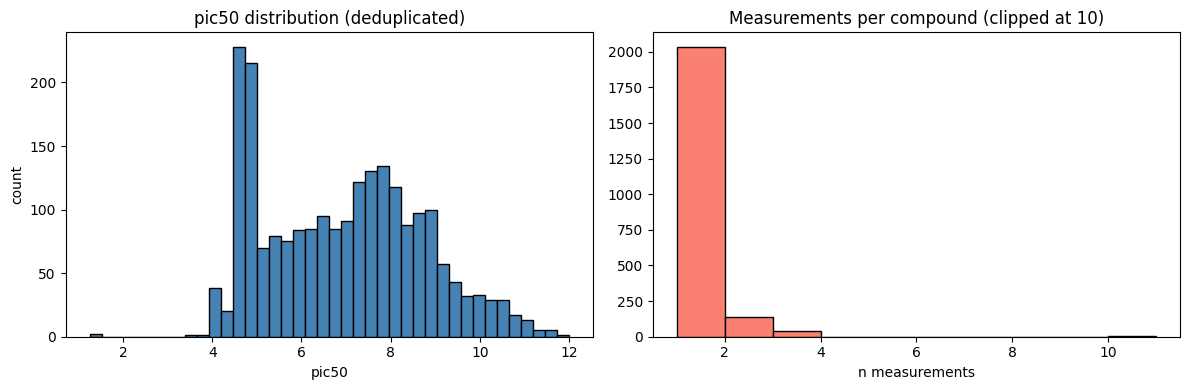

pic50 — mean: 6.93, std: 1.78, min: 1.25, max: 12.00


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_dedup['pic50'], bins=40, edgecolor='k', color='steelblue')
axes[0].set_title('pic50 distribution (deduplicated)')
axes[0].set_xlabel('pic50')
axes[0].set_ylabel('count')

axes[1].hist(df_dedup['n_measurements'].clip(upper=10), bins=range(1, 12), edgecolor='k', color='salmon')
axes[1].set_title('Measurements per compound (clipped at 10)')
axes[1].set_xlabel('n measurements')

plt.tight_layout()
plt.show()

print(f"pic50 — mean: {df_dedup['pic50'].mean():.2f}, std: {df_dedup['pic50'].std():.2f}, "
      f"min: {df_dedup['pic50'].min():.2f}, max: {df_dedup['pic50'].max():.2f}")

### 1.2 MLP features — Morgan fingerprints + physicochemical

We build a 2048-bit ECFP4 (Morgan radius=2) fingerprint for each compound and concatenate the 8 physicochemical descriptors from ChEMBL. Missing physicochemical values are imputed with the column median (mean-preserving for ~2k rows).

In [28]:
FP_RADIUS = 2
FP_BITS   = 2048

def smiles_to_fingerprint(smi: str) -> np.ndarray | None:
    """ECFP4 as a numpy binary array."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=FP_RADIUS, nBits=FP_BITS)
    return np.array(fp, dtype=np.float32)

fingerprints = df_dedup['canonical_smiles'].apply(smiles_to_fingerprint)
valid_mask   = fingerprints.notna()
print(f'Valid fingerprints: {valid_mask.sum()} / {len(df_dedup)}')

df_mlp = df_dedup[valid_mask].copy().reset_index(drop=True)
fp_matrix = np.vstack(fingerprints[valid_mask].values)   # (N, 2048)

# ── Physicochemical features ───────────────────────────────────────────────
phys_matrix = df_mlp[physchem_cols].values.astype(np.float32)

# Impute median for any remaining NaNs (keep data, don't drop rows)
col_medians = np.nanmedian(phys_matrix, axis=0)
nan_mask    = np.isnan(phys_matrix)
phys_matrix[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

# ── Concatenate: [2048 fp bits | 8 physchem] ─────────────────────────────
X_mlp = np.concatenate([fp_matrix, phys_matrix], axis=1)   # (N, 2056)
y_mlp = df_mlp['pic50'].values.astype(np.float32)

print(f'MLP feature matrix shape: {X_mlp.shape}')
print(f'Target vector shape:       {y_mlp.shape}')

[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerator
[22:41:18] DEPRECATION WARNING: please use MorganGenerat

Valid fingerprints: 2222 / 2222
MLP feature matrix shape: (2222, 2056)
Target vector shape:       (2222,)


[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerator
[22:41:20] DEPRECATION WARNING: please use MorganGenerat

In [29]:
# Save as parquet — fingerprint columns as fp_0 … fp_2047, physchem as-is
fp_col_names    = [f'fp_{i}' for i in range(FP_BITS)]
feature_cols    = fp_col_names + physchem_cols

df_mlp_out = pd.DataFrame(X_mlp, columns=feature_cols)
df_mlp_out.insert(0, 'canonical_smiles', df_mlp['canonical_smiles'].values)
df_mlp_out.insert(1, 'pic50',            y_mlp)
df_mlp_out.insert(2, 'n_measurements',   df_mlp['n_measurements'].values)

df_mlp_out.to_parquet(MLP_PARQUET, index=False)
print(f'Saved MLP features → {MLP_PARQUET}  ({df_mlp_out.shape})')

Saved MLP features → data\mlp_features_2147_mlp_special.parquet  ((2222, 2059))


### 1.3 GNN features — atom & bond graphs

Each molecule becomes a `torch_geometric.data.Data` object with:
- `x`: node (atom) feature matrix
- `edge_index`: bidirectional COO adjacency
- `edge_attr`: bond feature matrix
- `y`: pic50 scalar
- `smiles`: original canonical SMILES for reference

In [30]:
# ── Enhanced Atom & Bond Featurisation ───────────────────────────────────────
# Improvements over baseline:
#   • Atomic number (continuous)
#   • Chirality (R/S/unspec)
#   • Gasteiger partial charge (normalised)
#   • Smallest ring size the atom is part of
#   • Number of heavy-atom neighbours
#   • Bond stereo (E/Z/any)
#   • Bond direction

from rdkit.Chem import rdPartialCharges

ATOM_TYPES     = ['C','N','O','S','F','Cl','Br','I','P','Si','B','other']
HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
CHIRAL_TAGS = [
    Chem.rdchem.ChiralType.CHI_UNSPECIFIED,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW,
    Chem.rdchem.ChiralType.CHI_OTHER,
]

def one_hot(value, choices: list) -> list[int]:
    enc = [0] * len(choices)
    idx = choices.index(value) if value in choices else len(choices) - 1
    enc[idx] = 1
    return enc

def atom_features(atom, ring_info) -> list[float]:
    """
    Extended atom featurisation (42 dims):
      12 — atom type
       1 — atomic number / 53 (normalised)
       1 — degree / 6
       1 — formal charge / 4
       1 — total num Hs / 4
       1 — in ring (bool)
       1 — is aromatic (bool)
       5 — hybridisation
       4 — chirality
       1 — Gasteiger charge (clamped to [-1,1])
       1 — smallest ring size / 8 (0 if not in ring)
       1 — num heavy atom neighbours / 6
    ── total: 30
    """
    symbol = atom.GetSymbol()
    idx    = atom.GetIdx()

    # Smallest ring size
    smallest_ring = 0
    if ring_info is not None:
        for ring in ring_info.AtomRings():
            if idx in ring:
                size = len(ring)
                if smallest_ring == 0 or size < smallest_ring:
                    smallest_ring = size

    # Gasteiger charge (already computed on the mol)
    try:
        gasteiger = float(atom.GetDoubleProp('_GasteigerCharge'))
        if gasteiger != gasteiger:  # NaN guard
            gasteiger = 0.0
        gasteiger = max(-1.0, min(1.0, gasteiger))
    except KeyError:
        gasteiger = 0.0

    return [
        *one_hot(symbol, ATOM_TYPES),                      # 12
        atom.GetAtomicNum() / 53.0,                        #  1
        atom.GetDegree() / 6.0,                            #  1
        atom.GetFormalCharge() / 4.0,                      #  1
        atom.GetTotalNumHs() / 4.0,                        #  1
        int(atom.IsInRing()),                              #  1
        int(atom.GetIsAromatic()),                         #  1
        *one_hot(atom.GetHybridization(), HYBRIDIZATIONS), #  5
        *one_hot(atom.GetChiralTag(), CHIRAL_TAGS),        #  4
        gasteiger,                                         #  1
        smallest_ring / 8.0,                               #  1
        atom.GetDegree() / 6.0,                            #  1 (heavy nbrs proxy)
    ]
# Total: 12+1+1+1+1+1+1+5+4+1+1+1 = 30

BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
BOND_STEREO = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOE,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOANY,
]

def bond_features(bond) -> list[float]:
    """
    Extended bond featurisation (10 dims):
      4 — bond type
      4 — bond stereo
      1 — is in ring
      1 — is conjugated
    """
    return [
        *one_hot(bond.GetBondType(), BOND_TYPES),    # 4
        *one_hot(bond.GetStereo(), BOND_STEREO),     # 4
        int(bond.IsInRing()),                        # 1
        int(bond.GetIsConjugated()),                 # 1
    ]
# Total bond feature dim: 10

NODE_DIM   = 30
EDGE_DIM   = 10
PHYS_DIM   = 8   # mw_freebase, alogp, hba, hbd, psa, rtb, aromatic_rings, qed_weighted

print(f'Node feature dim: {NODE_DIM}, Edge feature dim: {EDGE_DIM}, Physchem dim: {PHYS_DIM}')


Node feature dim: 30, Edge feature dim: 10, Physchem dim: 8


In [31]:
def smiles_to_graph(smi: str, y_val: float, phys_vec: np.ndarray | None = None) -> Data | None:
    """
    Convert a SMILES string to a PyG Data object.
    Optional phys_vec (8-dim physicochemical vector) is stored as graph-level
    attribute `phys` and can be concatenated at readout for mixed GNN+physchem models.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None or mol.GetNumAtoms() == 0:
        return None

    # Compute Gasteiger charges (needed by extended atom_features)
    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except Exception:
        pass   # fallback: charges stay 0 in atom_features

    ring_info = mol.GetRingInfo()

    # Node features
    node_feats = torch.tensor(
        [atom_features(a, ring_info) for a in mol.GetAtoms()], dtype=torch.float
    )  # (num_atoms, 30)

    # Edges — bidirectional
    src, dst, edge_feats = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feats = bond_features(bond)
        src += [i, j]
        dst += [j, i]
        edge_feats += [feats, feats]

    if len(src) == 0:
        src, dst = [0], [0]
        edge_feats = [[0] * EDGE_DIM]

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(edge_feats, dtype=torch.float)

    # Physicochemical graph-level features
    if phys_vec is None:
        phys_vec = np.zeros(PHYS_DIM, dtype=np.float32)
    phys_tensor = torch.tensor(phys_vec, dtype=torch.float).unsqueeze(0)  # (1, 8)

    return Data(
        x          = node_feats,
        edge_index = edge_index,
        edge_attr  = edge_attr,
        y          = torch.tensor([y_val], dtype=torch.float),
        phys       = phys_tensor,
        smiles     = smi,
    )

# ── Build graph list with physicochemical features ─────────────────────────
physchem_cols = ['mw_freebase','alogp','hba','hbd','psa','rtb','aromatic_rings','qed_weighted']

# Build physchem matrix and impute medians (same logic as MLP branch)
phys_matrix = df_mlp[physchem_cols].values.astype(np.float32)
col_medians = np.nanmedian(phys_matrix, axis=0)
nan_mask    = np.isnan(phys_matrix)
phys_matrix[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

# Normalise physicochemical features (z-score, fit on full dataset — fine at this stage,
# exact train-only normalisation is applied inside load_gnn_split)
from sklearn.preprocessing import StandardScaler as _SS
_phys_scaler_global = _SS().fit(phys_matrix)
phys_matrix_norm = _phys_scaler_global.transform(phys_matrix)

graph_list = []
skipped    = 0
for smi, pic50, phys_vec in zip(df_mlp['canonical_smiles'], df_mlp['pic50'], phys_matrix_norm):
    g = smiles_to_graph(smi, pic50, phys_vec)
    if g is not None:
        graph_list.append(g)
    else:
        skipped += 1

print(f'Graphs built: {len(graph_list)}  |  skipped: {skipped}')
print(f'Example graph: {graph_list[0]}')
print(f'  x.shape={graph_list[0].x.shape}  edge_attr.shape={graph_list[0].edge_attr.shape}  phys.shape={graph_list[0].phys.shape}')


Graphs built: 2222  |  skipped: 0
Example graph: Data(x=[14, 30], edge_index=[2, 32], edge_attr=[32, 10], y=[1], phys=[1, 8], smiles='Brc1c[nH]c2cc3cnccc3cc12')
  x.shape=torch.Size([14, 30])  edge_attr.shape=torch.Size([32, 10])  phys.shape=torch.Size([1, 8])


In [32]:
torch.save(graph_list, GNN_PT)
print(f'Saved GNN graphs → {GNN_PT}')

# Sanity check — reload and print stats
graphs_check = torch.load(GNN_PT, weights_only=False)
num_nodes_list = [g.num_nodes for g in graphs_check]
print(f'Reloaded {len(graphs_check)} graphs')
print(f'Atoms per molecule — mean: {np.mean(num_nodes_list):.1f}, '
      f'min: {np.min(num_nodes_list)}, max: {np.max(num_nodes_list)}')
print(f'Node feature dim: {graphs_check[0].x.shape[1]}  (expected {NODE_DIM})')
print(f'Edge feature dim: {graphs_check[0].edge_attr.shape[1]}  (expected {EDGE_DIM})')
print(f'Physchem dim:     {graphs_check[0].phys.shape[1]}  (expected {PHYS_DIM})')


Saved GNN graphs → data\gnn_graphs_2147_gnn_special.pt
Reloaded 2222 graphs
Atoms per molecule — mean: 27.9, min: 12, max: 73
Node feature dim: 30  (expected 30)
Edge feature dim: 10  (expected 10)
Physchem dim:     8  (expected 8)


---
# Part 2 — Splitting

We produce **random** and **scaffold** splits for both MLP and GNN data.

Ratios: **70 / 10 / 20** (train / val / test) — conservative val set given ~2k compounds.

Splits are saved as index arrays so the same compound always lands in the same set regardless of model type.

In [33]:
# ── Load prepared data ────────────────────────────────────────────────────
df_mlp_feat = pd.read_parquet(MLP_PARQUET)
gnn_graphs  = torch.load(GNN_PT, weights_only=False)

# Both share the same SMILES → ensure alignment
assert len(df_mlp_feat) == len(gnn_graphs), \
    'MLP and GNN datasets are misaligned — re-run Part 1'

smiles_list = df_mlp_feat['canonical_smiles'].tolist()
N = len(smiles_list)
print(f'Total compounds: {N}')

VAL_FRAC  = 0.10
TEST_FRAC = 0.20

SPLIT_DIR = DATA_DIR / 'splits'
SPLIT_DIR.mkdir(exist_ok=True)

Total compounds: 2222


### 2.1 Random split

In [34]:
all_idx = np.arange(N)

train_idx, temp_idx = train_test_split(all_idx, test_size=VAL_FRAC + TEST_FRAC, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC), random_state=SEED)

random_split = {'train': train_idx, 'val': val_idx, 'test': test_idx}

for split_name, idx in random_split.items():
    np.save(SPLIT_DIR / f'random_{split_name}.npy', idx)

print(f'Random split — train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

Random split — train: 1555, val: 222, test: 445


### 2.2 Scaffold split

**What scaffold splitting does:** every molecule's Bemis-Murcko scaffold (the ring systems + linkers, stripped of substituents) is computed via RDKit. Molecules are grouped by scaffold. Groups are then sorted by frequency (largest first) and assigned: the biggest scaffolds go to the **training set**, smaller/rare ones are distributed across val and test. This ensures that **no scaffold appears in more than one split**, testing true generalisation to unseen chemical series — which is what matters in drug discovery.

In [35]:
def get_scaffold(smi: str) -> str:
    """
    Compute Bemis-Murcko scaffold SMILES.
    Falls back to the full canonical SMILES for acyclic molecules (no rings → empty scaffold).
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return scaffold if scaffold else smi


# Build scaffold → [indices] mapping
scaffold_to_indices: dict[str, list[int]] = defaultdict(list)
for idx, smi in enumerate(smiles_list):
    scaffold_to_indices[get_scaffold(smi)].append(idx)

# Sort scaffold groups largest-first
scaffold_sets = sorted(scaffold_to_indices.values(), key=len, reverse=True)

print(f'Unique scaffolds: {len(scaffold_sets)}')
print(f'Top-5 scaffold sizes: {[len(s) for s in scaffold_sets[:5]]}')

# ── Greedy test-first assignment (matches their pipeline.py scaffold_split) ──
# Fill TEST quota first, then VAL, then everything else → TRAIN.
# This is the correct direction: rare/novel scaffolds end up in test,
# which is harder and more realistic than filling train with the big scaffolds.
target_test = int(N * TEST_FRAC)
target_val  = int(N * VAL_FRAC)

sc_train, sc_val, sc_test = [], [], []
counts = {'train': 0, 'val': 0, 'test': 0}

for group in scaffold_sets:
    need_test = target_test - counts['test']
    need_val  = target_val  - counts['val']
    if need_test > 0 and need_test >= need_val:
        sc_test.extend(group);  counts['test'] += len(group)
    elif need_val > 0:
        sc_val.extend(group);   counts['val']  += len(group)
    else:
        sc_train.extend(group); counts['train'] += len(group)

scaffold_split = {
    'train': np.array(sc_train),
    'val':   np.array(sc_val),
    'test':  np.array(sc_test),
}

for split_name, idx in scaffold_split.items():
    np.save(SPLIT_DIR / f'scaffold_{split_name}.npy', idx)

print(f'Scaffold split — train: {len(sc_train)}, val: {len(sc_val)}, test: {len(sc_test)}')
print('Note: test-first greedy — novel/rare scaffolds go to test (harder, more realistic).')


Unique scaffolds: 1105
Top-5 scaffold sizes: [47, 42, 33, 27, 25]
Scaffold split — train: 1553, val: 223, test: 446
Note: test-first greedy — novel/rare scaffolds go to test (harder, more realistic).


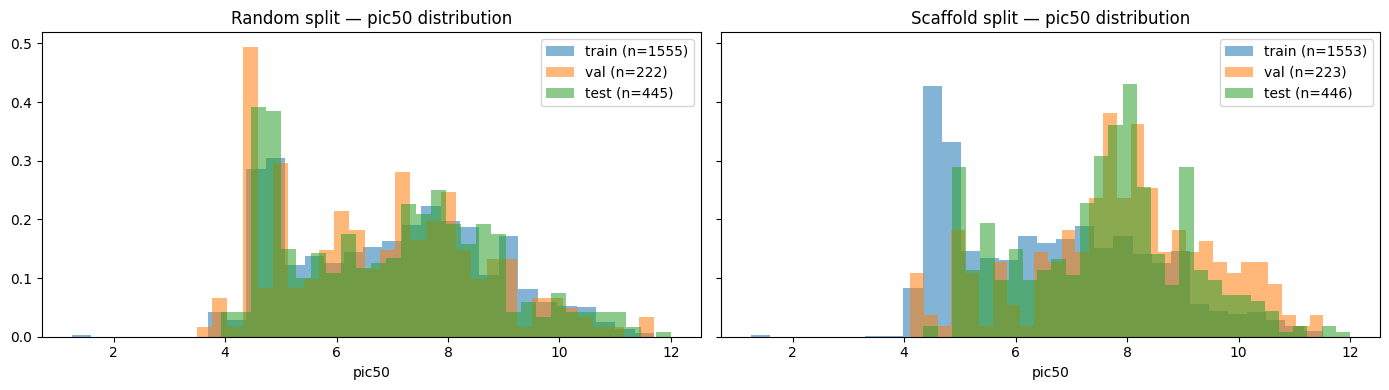

In [36]:
# Visualise pic50 distributions across splits to check for label shift
import matplotlib.pyplot as plt

y_all = df_mlp_feat['pic50'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (split_type, split_dict) in zip(axes, [
    ('Random',   random_split),
    ('Scaffold', scaffold_split),
]):
    for name, idx in split_dict.items():
        ax.hist(y_all[idx], bins=30, alpha=0.55, label=f'{name} (n={len(idx)})', density=True)
    ax.set_title(f'{split_type} split — pic50 distribution')
    ax.set_xlabel('pic50')
    ax.legend()

plt.tight_layout()
plt.show()
# Scaffold split will look less uniform — that's expected and correct.

---
# Part 3 — Model Experimentation

All experiments are tracked with **MLflow**. For each run:
- hyperparameters are logged as params
- per-epoch train/val loss is logged as metrics
- final test RMSE and R² are logged
- the best model checkpoint is saved as an artefact

Run `mlflow ui` in your terminal after to explore results.

In [37]:
mlflow.set_tracking_uri(str(MLFLOW_DIR))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Shared training helpers ────────────────────────────────────────────────

def evaluate_regression(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    return {'rmse': rmse, 'r2': r2, 'mae': mae}

def early_stop_check(val_losses: list[float], patience: int = 20) -> bool:
    """Return True if val loss hasn't improved in `patience` epochs."""
    if len(val_losses) <= patience:
        return False
    return min(val_losses[:-patience]) <= min(val_losses[-patience:])

print('Helpers defined.')

Device: cuda
Helpers defined.


## 3A — MLP Experiments

In [38]:
# ── MLP dataset helpers ───────────────────────────────────────────────────

def load_mlp_split(split_type: str):
    """
    Loads train/val/test index arrays and returns:
    - Scaled X tensors
    - y tensors
    - StandardScaler (fit on train only)
    """
    feature_cols = [c for c in df_mlp_feat.columns
                    if c not in ('canonical_smiles', 'pic50', 'n_measurements')]
    X = df_mlp_feat[feature_cols].values.astype(np.float32)
    y = df_mlp_feat['pic50'].values.astype(np.float32)

    tr_idx  = np.load(SPLIT_DIR / f'{split_type}_train.npy')
    val_idx = np.load(SPLIT_DIR / f'{split_type}_val.npy')
    te_idx  = np.load(SPLIT_DIR / f'{split_type}_test.npy')

    # Scale: fit on train, apply to all — only the non-fingerprint columns need scaling
    # Fingerprint bits are already 0/1, scaling them mildly degrades performance
    fp_bits = 2048
    scaler  = StandardScaler()
    X[tr_idx,  fp_bits:] = scaler.fit_transform(X[tr_idx,  fp_bits:])
    X[val_idx, fp_bits:] = scaler.transform(X[val_idx, fp_bits:])
    X[te_idx,  fp_bits:] = scaler.transform(X[te_idx,  fp_bits:])

    to_t = lambda idx: (
        torch.tensor(X[idx], dtype=torch.float32),
        torch.tensor(y[idx], dtype=torch.float32).unsqueeze(1),
    )
    return (*to_t(tr_idx), *to_t(val_idx), *to_t(te_idx), scaler)

In [39]:
# ── MLP model factory ─────────────────────────────────────────────────────

class MLP(nn.Module):
    """
    Flexible MLP for pic50 regression.
    
    Architecture: Linear → [BN → Dropout → activation → Linear] × n_layers → output
    """
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        dropout: float       = 0.3,
        use_batchnorm: bool  = True,
        activation: str      = 'relu',
    ):
        super().__init__()
        act_fn = {'relu': nn.ReLU, 'gelu': nn.GELU, 'silu': nn.SiLU}[activation]

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp(
    config: dict,
    split_type: str,
    experiment_name: str = 'MLP_experiments',
) -> dict:
    """
    Train one MLP config, log everything to MLflow, return test metrics.
    """
    X_tr, y_tr, X_val, y_val, X_te, y_te, _ = load_mlp_split(split_type)

    train_loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=config['batch_size'], shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=256, shuffle=False,
    )

    model = MLP(
        input_dim     = X_tr.shape[1],
        hidden_dims   = config['hidden_dims'],
        dropout       = config['dropout'],
        use_batchnorm = config.get('batchnorm', True),
        activation    = config.get('activation', 'relu'),
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config.get('wd', 1e-5))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    loss_fn   = nn.HuberLoss(delta=1.0)  # robust to pic50 noise

    mlflow.set_experiment(experiment_name)
    run_name = f"mlp_{split_type}_{'_'.join(map(str, config['hidden_dims']))}_{config['dropout']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({**config, 'split': split_type, 'model_type': 'MLP'})

        best_val_loss = float('inf')
        best_state    = None
        val_losses    = []
        patience      = config.get('patience', 30)

        for epoch in range(1, config['epochs'] + 1):
            # Train
            model.train()
            train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * len(xb)
            train_loss /= len(train_loader.dataset)

            # Validate
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    val_loss += loss_fn(model(xb), yb).item() * len(xb)
            val_loss /= len(val_loader.dataset)
            val_losses.append(val_loss)
            scheduler.step(val_loss)

            mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss}, step=epoch)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state    = copy.deepcopy(model.state_dict())

            if early_stop_check(val_losses, patience):
                print(f'  Early stop at epoch {epoch}')
                break

        # Test evaluation with best weights
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            y_pred = model(X_te.to(DEVICE)).cpu().numpy().flatten()
        y_true = y_te.numpy().flatten()

        metrics = evaluate_regression(y_true, y_pred)
        mlflow.log_metrics({f'test_{k}': v for k, v in metrics.items()})
        mlflow.pytorch.log_model(model, 'model')

        print(f'  [{run_name}]  RMSE={metrics["rmse"]:.3f}  R²={metrics["r2"]:.3f}')
        return metrics

In [40]:
# ── MLP experiment grid ───────────────────────────────────────────────────
# Each config is one MLflow run, tried on both split types

mlp_configs = [
    # Baseline — shallow
    dict(hidden_dims=[512, 256],          dropout=0.3, lr=1e-3, batch_size=64,  epochs=200, patience=30, name='shallow'),
    # Deeper
    dict(hidden_dims=[1024, 512, 256],    dropout=0.3, lr=1e-3, batch_size=64,  epochs=200, patience=30, name='deep_3'),
    dict(hidden_dims=[1024, 512, 256, 128], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, name='deep_4'),
    # Higher dropout — more regularisation for small data
    dict(hidden_dims=[1024, 512, 256],    dropout=0.5, lr=1e-3, batch_size=64,  epochs=200, patience=30, name='deep_high_drop'),
    # GELU activation
    dict(hidden_dims=[1024, 512, 256],    dropout=0.3, lr=1e-3, batch_size=64,  epochs=200, patience=30, activation='gelu', name='gelu'),
    # No batchnorm
    dict(hidden_dims=[1024, 512, 256],    dropout=0.3, lr=1e-3, batch_size=64,  epochs=200, patience=30, batchnorm=False, name='no_bn'),
    # Smaller LR
    dict(hidden_dims=[1024, 512, 256],    dropout=0.3, lr=3e-4, batch_size=64,  epochs=300, patience=40, name='low_lr'),
]

mlp_results = []
for cfg in mlp_configs:
    for split in ['random', 'scaffold']:
        print(f'\nRunning MLP [{cfg["name"]}] | split={split}')
        metrics = train_mlp(cfg, split_type=split, experiment_name='MLP_experiments')
        mlp_results.append({'config': cfg['name'], 'split': split, **metrics})

pd.DataFrame(mlp_results).sort_values('rmse')


Running MLP [shallow] | split=random


2026/06/06 22:41:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 22:41:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/06 22:41:35 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 125


2026/06/06 22:41:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_random_512_256_0.3]  RMSE=0.767  R²=0.820

Running MLP [shallow] | split=scaffold


...

2026/06/06 22:44:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 22:44:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/06 22:44:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 111


2026/06/06 22:44:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_1024_512_256_0.3]  RMSE=0.876  R²=0.668


,config,split,rmse,r2,mae
4,deep_4,random,0.733801,0.835009,0.528153
8,gelu,random,0.738366,0.832950,0.535276
6,deep_high_drop,random,0.750064,0.827615,0.541869
0,shallow,random,0.767424,0.819543,0.565258
2,deep_3,random,0.770026,0.818317,0.548888
9,gelu,scaffold,0.786604,0.732839,0.577326
3,deep_3,scaffold,0.790639,0.730090,0.580157
12,low_lr,random,0.801441,0.803190,0.598088
1,shallow,scaffold,0.813076,0.714554,0.599319
10,no_bn,random,0.823789,0.792061,0.610340


## 3B — GNN Experiments

In [41]:
# ── GNN dataset helpers ──────────────────────────────────────────────────────

def load_gnn_split(split_type: str):
    """
    Loads graphs and split indices.
    Re-normalises the .phys attribute: scaler fit on train only, applied to val/test.
    Returns: tr_graphs, val_graphs, te_graphs  (Data objects with .phys already scaled)
    """
    graphs   = torch.load(GNN_PT, weights_only=False)
    tr_idx   = np.load(SPLIT_DIR / f'{split_type}_train.npy')
    val_idx  = np.load(SPLIT_DIR / f'{split_type}_val.npy')
    te_idx   = np.load(SPLIT_DIR / f'{split_type}_test.npy')

    # Re-normalise phys using train distribution
    phys_train = np.vstack([graphs[i].phys.numpy() for i in tr_idx])  # (N_tr, 8)
    phys_scaler = StandardScaler().fit(phys_train)

    import copy
    def scale_graphs(idx_list):
        out = []
        for i in idx_list:
            g = copy.copy(graphs[i])
            phys_scaled = phys_scaler.transform(g.phys.numpy())
            g.phys = torch.tensor(phys_scaled, dtype=torch.float)
            out.append(g)
        return out

    return (
        scale_graphs(tr_idx),
        scale_graphs(val_idx),
        scale_graphs(te_idx),
    )


## 3B — GNN Experiments (Enhanced)

### What changed vs baseline:
- **Richer featurisation** (30-dim atom, 10-dim bond) including Gasteiger charges, chirality, stereo
- **Physicochemical features** attached as graph-level attributes (`phys`) — injected at readout in mixed models
- **Residual GINE** — skip connections in every conv layer to ease gradient flow
- **Mixed GNN+Physchem model** — fuses graph readout with the 8 ChEMBL physchem descriptors before the regression head
- **Experiment configs** cover: baseline, residual, mixed, AttentiveFP variants, and combinations


In [42]:
# ── GNNRegressor — mirrors their pipeline.py architecture ─────────────────────
# Key difference from ResidualGINEModel: edge features are projected through a
# 2-layer MLP *before* entering GINEConv (edge_encoder). This puts node and edge
# representations in the same learned space before the GIN sum, which is more
# principled than feeding raw heterogeneous features directly.

class GNNRegressor(nn.Module):
    """
    GINE with:
      - edge_encoder MLP: raw bond features → hidden_dim before message passing
      - residual skip on every conv layer
      - BatchNorm (PyG flavour) after each conv
      - mean OR add global pooling (configurable)
      - small MLP head
    """
    def __init__(
        self,
        node_dim:    int,
        edge_dim:    int,
        hidden_dim:  int   = 128,
        n_layers:    int   = 4,
        dropout:     float = 0.15,
        pooling:     str   = 'mean',
    ):
        super().__init__()
        assert pooling in {'mean', 'add'}, "pooling must be 'mean' or 'add'"
        self.pooling = pooling
        self.dropout_p = dropout

        self.node_proj = nn.Linear(node_dim, hidden_dim)

        # Projects raw bond features into hidden_dim space before message passing
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(mlp, edge_dim=hidden_dim))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        x         = self.node_proj(x)
        edge_attr = self.edge_encoder(edge_attr)   # ← key difference

        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_attr)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout_p, training=self.training)
            x = x + residual                       # residual skip

        if self.pooling == 'add':
            x = global_add_pool(x, batch)
        else:
            x = global_mean_pool(x, batch)

        return self.head(x)


# ── GNN model definitions ────────────────────────────────────────────────────

class ResidualGINEModel(nn.Module):
    """
    GINE with residual connections + optional physicochemical feature fusion.

    When `use_physchem=True` the graph-level `phys` attribute (8-dim) is
    concatenated to the pooled graph representation before the regression head.
    This is the "mixed" model: structure + physicochemical.
    """
    def __init__(
        self,
        node_dim:    int,
        edge_dim:    int,
        phys_dim:    int   = 0,   # 0 = no physchem fusion
        hidden_dim:  int   = 256,
        n_layers:    int   = 4,
        dropout:     float = 0.3,
        readout_mlp: list  = None,
        use_residual: bool = True,
    ):
        super().__init__()
        readout_mlp = readout_mlp or [512, 256]
        self.use_residual = use_residual

        self.node_embed = nn.Linear(node_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for _ in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.GELU(),
                nn.Linear(hidden_dim * 2, hidden_dim),
            )
            self.convs.append(GINEConv(mlp, edge_dim=edge_dim, train_eps=True))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Dual readout: mean + add
        readout_input = hidden_dim * 2 + phys_dim   # fuse physchem here
        head_layers = []
        in_d = readout_input
        for h in readout_mlp:
            head_layers += [nn.Linear(in_d, h), nn.GELU(), nn.Dropout(dropout)]
            in_d = h
        head_layers.append(nn.Linear(in_d, 1))
        self.head    = nn.Sequential(*head_layers)
        self.dropout = nn.Dropout(dropout)
        self.phys_dim = phys_dim

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        x = self.node_embed(x)
        for conv, bn in zip(self.convs, self.bns):
            x_new = F.gelu(bn(conv(x, edge_index, edge_attr)))
            x_new = self.dropout(x_new)
            if self.use_residual:
                x = x + x_new     # residual skip
            else:
                x = x_new

        x_mean = global_mean_pool(x, batch)
        x_add  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_add], dim=1)

        if self.phys_dim > 0:
            # data.phys is (1, phys_dim) per graph — already batched to (B, phys_dim) by PyG
            x_pool = torch.cat([x_pool, data.phys], dim=1)

        return self.head(x_pool)


class AttentiveFPModel(nn.Module):
    """
    Wrapper around PyG's AttentiveFP with optional physicochemical fusion.
    When use_physchem=True the 8-dim phys vector is concatenated before a
    small final MLP head.
    """
    def __init__(
        self,
        node_dim:     int,
        edge_dim:     int,
        phys_dim:     int   = 0,
        hidden_dim:   int   = 200,
        n_layers:     int   = 4,
        n_timesteps:  int   = 2,
        dropout:      float = 0.3,
    ):
        super().__init__()
        self.phys_dim = phys_dim
        # AttentiveFP outputs hidden_dim-dim graph embedding (out_channels=hidden_dim)
        # We add our own head so we can fuse physchem
        self.gnn = AttentiveFP(
            in_channels     = node_dim,
            hidden_channels = hidden_dim,
            out_channels    = hidden_dim,   # embedding, not scalar
            edge_dim        = edge_dim,
            num_layers      = n_layers,
            num_timesteps   = n_timesteps,
            dropout         = dropout,
        )
        head_in = hidden_dim + phys_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data):
        emb = self.gnn(data.x, data.edge_index, data.edge_attr, data.batch)
        if self.phys_dim > 0:
            emb = torch.cat([emb, data.phys], dim=1)
        return self.head(emb)


print('GNN model classes defined.')


GNN model classes defined.


In [43]:
def train_gnn(
    config: dict,
    split_type: str,
    experiment_name: str = 'GNN_experiments',
) -> dict:
    """
    Train one GNN config, log everything to MLflow, return test metrics.
    config keys:
        model_type     : 'gine' | 'attentivefp'
        use_physchem   : bool  — inject physchem vector at readout (default False)
        use_residual   : bool  — residual GINE convs (default True)
        hidden_dim, n_layers, dropout, lr, batch_size, epochs, patience
        readout_mlp    : list of hidden dims for GINE head (default [512,256])
        n_timesteps    : AttentiveFP only
    """
    tr_graphs, val_graphs, te_graphs = load_gnn_split(split_type)

    train_loader = GeoDataLoader(tr_graphs,  batch_size=config['batch_size'], shuffle=True)
    val_loader   = GeoDataLoader(val_graphs, batch_size=128,  shuffle=False)
    test_loader  = GeoDataLoader(te_graphs,  batch_size=128,  shuffle=False)

    model_type   = config.get('model_type', 'gine')
    use_physchem = config.get('use_physchem', False)
    phys_dim     = PHYS_DIM if use_physchem else 0

    if model_type == 'gner':
        model = GNNRegressor(
            node_dim   = NODE_DIM,
            edge_dim   = EDGE_DIM,
            hidden_dim = config['hidden_dim'],
            n_layers   = config['n_layers'],
            dropout    = config['dropout'],
            pooling    = config.get('pooling', 'mean'),
        )
    elif model_type == 'gine':
        model = ResidualGINEModel(
            node_dim     = NODE_DIM,
            edge_dim     = EDGE_DIM,
            phys_dim     = phys_dim,
            hidden_dim   = config['hidden_dim'],
            n_layers     = config['n_layers'],
            dropout      = config['dropout'],
            readout_mlp  = config.get('readout_mlp', [512, 256]),
            use_residual = config.get('use_residual', True),
        )
    elif model_type == 'attentivefp':
        model = AttentiveFPModel(
            node_dim    = NODE_DIM,
            edge_dim    = EDGE_DIM,
            phys_dim    = phys_dim,
            hidden_dim  = config['hidden_dim'],
            n_layers    = config['n_layers'],
            n_timesteps = config.get('n_timesteps', 2),
            dropout     = config['dropout'],
        )
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config.get('wd', 1e-4))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=config['lr'] * 0.01
    )
    loss_fn = nn.HuberLoss(delta=1.0)

    physchem_tag = 'mixed' if use_physchem else 'graphonly'
    residual_tag = 'res' if (config.get('use_residual', True) and model_type == 'gine') or model_type == 'gner' else 'nores'
    run_name = (
        f"gnn_{model_type}_{physchem_tag}_{residual_tag}_{split_type}"
        f"_{config['hidden_dim']}h_{config['n_layers']}l"
    )

    mlflow.set_experiment(experiment_name)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({**config, 'split': split_type, 'model_type': model_type,
                           'use_physchem': use_physchem, 'physchem_tag': physchem_tag})

        best_val_loss = float('inf')
        best_state    = None
        val_losses    = []
        patience      = config.get('patience', 30)

        for epoch in range(1, config['epochs'] + 1):
            model.train()
            train_loss = 0.0
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                pred = model(batch)
                loss = loss_fn(pred, batch.y.unsqueeze(1))
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * batch.num_graphs
            train_loss /= len(tr_graphs)
            scheduler.step()

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(DEVICE)
                    val_loss += loss_fn(model(batch), batch.y.unsqueeze(1)).item() * batch.num_graphs
            val_loss /= len(val_graphs)
            val_losses.append(val_loss)

            mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss}, step=epoch)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state    = copy.deepcopy(model.state_dict())

            if early_stop_check(val_losses, patience):
                print(f'  Early stop at epoch {epoch}')
                break

        model.load_state_dict(best_state)
        model.eval()
        y_preds, y_trues = [], []
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(DEVICE)
                y_preds.append(model(batch).cpu().numpy().flatten())
                y_trues.append(batch.y.cpu().numpy().flatten())

        y_pred  = np.concatenate(y_preds)
        y_true  = np.concatenate(y_trues)
        metrics = evaluate_regression(y_true, y_pred)

        mlflow.log_metrics({f'test_{k}': v for k, v in metrics.items()})
        mlflow.pytorch.log_model(model, 'model')

        print(f'  [{run_name}]  RMSE={metrics["rmse"]:.3f}  R²={metrics["r2"]:.3f}')
        return metrics


In [44]:
# ── GNN Experiment Grid — Enhanced ──────────────────────────────────────────
#
# Strategy: run each config on scaffold split only (that's the hard one).
# Add random split for the best configs at the end to verify no regression.
#
# Legend:
#   graph-only  — uses richer atom/bond features, no physchem at readout
#   mixed       — graph + physchem fusion (use_physchem=True)
#   residual    — GINE with skip connections (default True)

gnn_configs = [
    # ────────────────────────────────────────────────────────────────────────
    # GNNRegressor — their architecture (edge_encoder + residual + single pool)
    # ────────────────────────────────────────────────────────────────────────
    dict(model_type='gner', hidden_dim=128, n_layers=4, dropout=0.15, pooling='mean',
         lr=3e-4, batch_size=64, epochs=250, patience=35,
         name='gner_128_4l_mean'),

    dict(model_type='gner', hidden_dim=256, n_layers=4, dropout=0.15, pooling='mean',
         lr=3e-4, batch_size=64, epochs=250, patience=35,
         name='gner_256_4l_mean'),

    dict(model_type='gner', hidden_dim=128, n_layers=4, dropout=0.15, pooling='add',
         lr=3e-4, batch_size=64, epochs=250, patience=35,
         name='gner_128_4l_add'),

    dict(model_type='gner', hidden_dim=128, n_layers=6, dropout=0.15, pooling='mean',
         lr=3e-4, batch_size=64, epochs=300, patience=40,
         name='gner_128_6l_mean'),

    dict(model_type='gner', hidden_dim=128, n_layers=4, dropout=0.25, pooling='mean',
         lr=1e-3, batch_size=64, epochs=250, patience=35,
         name='gner_128_4l_drop25'),


    # ────────────────────────────────────────────────────────────────────────
    # 1. GINE baselines (graph-only, residual) — establishes new feature baseline
    # ────────────────────────────────────────────────────────────────────────
    dict(model_type='gine', use_physchem=False, use_residual=True,
         hidden_dim=256, n_layers=4, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35, readout_mlp=[512,256],
         name='gine_res_256_4l'),

    dict(model_type='gine', use_physchem=False, use_residual=True,
         hidden_dim=512, n_layers=4, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35, readout_mlp=[512,256],
         name='gine_res_512_4l'),

    # No residual — ablation
    dict(model_type='gine', use_physchem=False, use_residual=False,
         hidden_dim=256, n_layers=4, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35, readout_mlp=[512,256],
         name='gine_nores_256_4l'),

    # ────────────────────────────────────────────────────────────────────────
    # 2. Mixed: GINE + physicochemical fusion
    # ────────────────────────────────────────────────────────────────────────
    dict(model_type='gine', use_physchem=True, use_residual=True,
         hidden_dim=256, n_layers=4, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35, readout_mlp=[512,256],
         name='gine_mixed_256_4l'),

    dict(model_type='gine', use_physchem=True, use_residual=True,
         hidden_dim=512, n_layers=4, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35, readout_mlp=[512,256],
         name='gine_mixed_512_4l'),

    # Deeper mixed
    dict(model_type='gine', use_physchem=True, use_residual=True,
         hidden_dim=256, n_layers=6, dropout=0.3,
         lr=5e-4, batch_size=32, epochs=300, patience=40, readout_mlp=[512,256],
         name='gine_mixed_256_6l'),

    # Higher dropout for scaffold generalisation
    dict(model_type='gine', use_physchem=True, use_residual=True,
         hidden_dim=256, n_layers=4, dropout=0.5,
         lr=1e-3, batch_size=32, epochs=300, patience=40, readout_mlp=[512,256],
         name='gine_mixed_256_4l_drop50'),

    # Small LR + cosine decay — often best for scaffold
    dict(model_type='gine', use_physchem=True, use_residual=True,
         hidden_dim=256, n_layers=4, dropout=0.3,
         lr=3e-4, batch_size=32, epochs=350, patience=50, readout_mlp=[512,256],
         name='gine_mixed_256_4l_lowlr'),

    # ────────────────────────────────────────────────────────────────────────
    # 3. AttentiveFP — graph-only and mixed
    # ────────────────────────────────────────────────────────────────────────
    dict(model_type='attentivefp', use_physchem=False,
         hidden_dim=200, n_layers=4, n_timesteps=2, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35,
         name='afp_graphonly_200'),

    dict(model_type='attentivefp', use_physchem=True,
         hidden_dim=200, n_layers=4, n_timesteps=2, dropout=0.3,
         lr=1e-3, batch_size=32, epochs=250, patience=35,
         name='afp_mixed_200'),

    dict(model_type='attentivefp', use_physchem=True,
         hidden_dim=200, n_layers=4, n_timesteps=4, dropout=0.3,
         lr=3e-4, batch_size=32, epochs=300, patience=40,
         name='afp_mixed_200_4ts'),

    dict(model_type='attentivefp', use_physchem=True,
         hidden_dim=300, n_layers=5, n_timesteps=2, dropout=0.25,
         lr=5e-4, batch_size=32, epochs=300, patience=40,
         name='afp_mixed_300'),
]

# Run scaffold split for all configs; run random too for the mixed ones
gnn_results = []
for cfg in gnn_configs:
    splits_to_run = ['scaffold']
    if cfg.get('use_physchem', False) or cfg.get('model_type') == 'gner':
        splits_to_run.append('random')
    for split in splits_to_run:
        print(f'\nRunning GNN [{cfg["name"]}] | split={split}')
        metrics = train_gnn(cfg, split_type=split, experiment_name='GNN_experiments')
        gnn_results.append({'model': cfg['name'], 'split': split, **metrics})

df_gnn_res = pd.DataFrame(gnn_results)
print('\n=== GNN Results (scaffold sorted by R²) ===')
print(df_gnn_res[df_gnn_res['split']=='scaffold'].sort_values('r2', ascending=False).to_string(index=False))



Running GNN [gner_128_4l_mean] | split=scaffold


2026/06/06 22:45:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 22:45:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/06 22:45:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 99


2026/06/06 22:45:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [gnn_gner_graphonly_res_scaffold_128h_4l]  RMSE=0.974  R²=0.590

Running GNN [gner_128_4l_mean] | split=random


...

2026/06/06 23:10:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 23:10:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  Early stop at epoch 162


2026/06/06 23:10:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/06 23:10:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [gnn_attentivefp_mixed_nores_random_200h_4l]  RMSE=0.871  R²=0.768

Running GNN [afp_mixed_200_4ts] | split=scaffold


KeyboardInterrupt: 

## Results Summary

In [45]:
import matplotlib.pyplot as plt

df_mlp_res = pd.DataFrame(mlp_results)
df_gnn_res = pd.DataFrame(gnn_results)

print('=== MLP Results ===')
print(df_mlp_res.sort_values(['split','rmse']).to_string(index=False))

print('\n=== GNN Results ===')
print(df_gnn_res.sort_values(['split','rmse']).to_string(index=False))

=== MLP Results ===
        config    split     rmse       r2      mae
        deep_4   random 0.733801 0.835009 0.528153
          gelu   random 0.738366 0.832950 0.535276
deep_high_drop   random 0.750064 0.827615 0.541869
       shallow   random 0.767424 0.819543 0.565258
        deep_3   random 0.770026 0.818317 0.548888
        low_lr   random 0.801441 0.803190 0.598088
         no_bn   random 0.823789 0.792061 0.610340
          gelu scaffold 0.786604 0.732839 0.577326
        deep_3 scaffold 0.790639 0.730090 0.580157
       shallow scaffold 0.813076 0.714554 0.599319
        deep_4 scaffold 0.825087 0.706059 0.593998
deep_high_drop scaffold 0.851326 0.687065 0.667918
        low_lr scaffold 0.876229 0.668490 0.662200
         no_bn scaffold 0.974561 0.589910 0.717141

=== GNN Results ===
                   model    split     rmse        r2      mae
        gner_128_4l_mean   random 0.797409  0.805165 0.610178
        gner_128_6l_mean   random 0.826737  0.790570 0.632789
        

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_res, title) in zip(axes, [
    (df_mlp_res, 'MLP — test RMSE by config & split'),
    (df_gnn_res, 'GNN — test RMSE by config & split'),
]):
    label_col = 'config' if 'config' in df_res.columns else 'model'
    for split_type, grp in df_res.groupby('split'):
        ax.scatter(grp[label_col], grp['rmse'], label=split_type, s=80)
    ax.set_title(title)
    ax.set_ylabel('Test RMSE (lower=better)')
    ax.set_xlabel('Config')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Split')
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print('\nTo explore full run details, open a terminal and run:')
print('  mlflow ui --backend-store-uri mlruns')

In [ ]:
# ── Quick guide to reading the results ───────────────────────────────────
"""
Key things to look at when comparing runs in MLflow UI:

1. Random vs Scaffold RMSE gap
   - A gap > 0.3–0.4 RMSE units suggests overfitting to seen scaffolds.
   - Prefer models where the gap is small — they generalise to new chemotypes.

2. R² on scaffold test
   - R² > 0.5 on scaffold split is a good result for ~2k compounds.
   - R² < 0 means the model is worse than the mean predictor — serious underfitting.

3. Val loss curve shape (in MLflow UI → select run → Metrics)
   - Smooth descent + plateau = good training
   - Noisy / oscillating = lower LR or add gradient clipping
   - Val loss rises after a dip = classic overfitting, needs more dropout or smaller model

4. Model selection rule:
   - Best model = lowest scaffold test RMSE (not random test RMSE)
   - Tie-break on R²

5. MLflow UI comparison:
   - Select multiple runs → 'Compare' → parallel coordinates plot
   - Useful to see which hyperparameters actually matter
"""
print('See docstring above for result interpretation guidance.')